In [1]:
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['OPENAI_API_KEY']:
    print("OpenAI API Key is set.")
else:
    raise ValueError("OpenAI API Key is not set.")

OpenAI API Key is set.


In [2]:
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-5-nano")

llm.invoke([HumanMessage(content="I want to know the meaning of water")]).content

'Here are the main ways to understand "water":\n\n- Scientific definition\n  - Water is a chemical compound with the formula H2O: two hydrogen atoms bonded to one oxygen atom.\n  - It is a liquid at most Earth-surface temperatures, but can be solid (ice) or gas (steam) under other conditions.\n  - It is a polar molecule and a very good solvent, meaning many substances dissolve in it. It also has strong hydrogen bonding, giving it unique properties like high heat capacity and surface tension.\n\n- Key properties and phenomena\n  - Water is most notable for: high heat capacity, high heat of vaporization, surface tension, and the fact that ice is less dense than liquid water (ice floats).\n  - It exists in three phases: solid (ice), liquid, and gas (steam), and can transition between them with changing temperature or pressure.\n  - In pure form, water is colorless and tasteless; in nature, it often contains dissolved minerals and tiny particles that affect its taste and color.\n\n- Natura

In [3]:
from typing import TypedDict,List, Annotated
from operator import add 

class graph_schema(TypedDict):

    messages_manual: List
    #Using Reducer in Langgraph
    messages_auto: Annotated[List,add]

In [4]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:

    messages_manual = state['messages_manual']
    response_manual = llm.invoke(messages_manual).content 
    response__manual_ai = AIMessage(content=response_manual)
    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]

    return state


def curate_post(state: graph_schema) -> graph_schema:


    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response__manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]


    return state

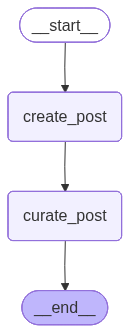

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(messages_graph.get_graph().draw_mermaid_png())

In [6]:
messages_graph.invoke(
    {"messages_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
     "messages_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
)

{'messages_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='The importance of data privacy in the digital age\n\nWhat data privacy means\n- Data privacy is about control over personal information: what is collected, how it is used, who it is shared with, and how long it is kept.\n- It also encompasses the rights to access, correct, delete, and move your data, and to set boundaries on surveillance and profiling.\n\nWhy it matters\n- Autonomy and dignity: Individuals should decide how their personal information shapes their lives, opportunities, and reputations.\n- Trust and safety: When users know their data is protected, they are more likely to engage with digital services, essential for healthy online ecosystems.\n- Protection from harm: Data exposure can lead to identity theft, financial loss, stalking, harassment, or discrimination.\n- Civic and social implications: Broad data collec